# Crescimento Populacional
Fonte de dados: Estudos Populacionais dos dados IBGE da empresa

# População por Sexo
Fonte de dados: https://censo2022.ibge.gov.br/panorama/?utm_source=ibge&utm_medium=home&utm_campaign=portal

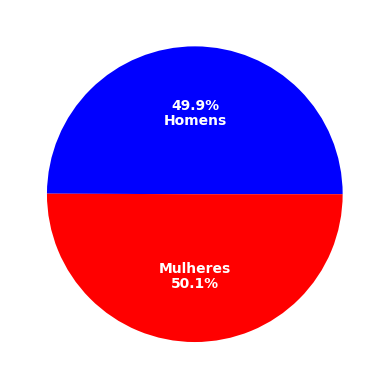

In [8]:
# Valores
h = 13733
m = 13765

import pandas as pd
import matplotlib.pyplot as plt

def plot_pie_chart(values, labels, colors, filename=None):
    # Plotando o gráfico de pizza
    patches, texts, autotexts = plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', textprops={'color': 'white', 'weight': 'bold'}, labeldistance=0.5)

    # Ajustando as cores das porcentagens
    for autotext in autotexts:
        autotext.set_color('white')  # Cor das porcentagens

    # Ajustando a posição dos labels
    for text in texts:
        text.set_horizontalalignment('center')  # Centralizar horizontalmente

    # Salvando a figura se um nome de arquivo for fornecido
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

# Rótulos
labels = ['Homens', 'Mulheres']

# Valores para os segmentos
pop = [h, m]

# Cores para os segmentos
colors = ['blue', 'red']

# Gerando o gráfico de pizza
plot_pie_chart(pop, labels, colors, 'população_por_sexo.png')

# Pirâmide etária
Fonte de dados: https://censo2022.ibge.gov.br/panorama/?utm_source=ibge&utm_medium=home&utm_campaign=portal

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


caminho_csv = rf'inserir caminho aqui' #caminho do documento XXX do panorama
pop = 27498 #população municipal último censo

def plot_piramide_etaria(dataframe, save_path=None):
    # Calculando as porcentagens
    dataframe['Porcentagem M'] = dataframe['População masculina(pessoas)'] / pop
    dataframe['Porcentagem F'] = dataframe['População feminina(pessoas)'] / pop

    # Invertendo a ordem dos dados
    dataframe = dataframe.iloc[::-1]

    # Plotando a pirâmide etária
    plt.figure(figsize=(10, 8))
    bars_m = plt.barh(dataframe['Grupo de idade'], dataframe['População masculina(pessoas)'] + 500, color='blue', label='Masculino')
    bars_f = plt.barh(dataframe['Grupo de idade'], -(dataframe['População feminina(pessoas)'] + 500), color='red', label='Feminino')

    # Adicionando os labels nas barras
    plt.bar_label(bars_m, labels=[f'{p * 100:.2f}%' for p in dataframe['Porcentagem M']], label_type='edge', color='blue', fontsize=8, fontweight='bold')
    plt.bar_label(bars_f, labels=[f'{p * 100:.2f}%' for p in dataframe['Porcentagem F']], label_type='edge', color='red', fontsize=8, fontweight='bold')

    # Adicionando os rótulos do eixo y no meio
    for i, label in enumerate(dataframe['Grupo de idade']):
        plt.text(0, i, label, ha='center', va='center', color='black', fontsize=9)

    # Adicionando os textos "Homens" e "Mulheres" na parte superior esquerda e direita, respectivamente
    plt.text(800, len(dataframe) + 1, 'Homens', ha='right', va='center', color='blue', fontsize=12, fontweight='bold')
    plt.text(-800, len(dataframe) + 1, 'Mulheres', ha='left', va='center', color='red', fontsize=12, fontweight='bold')

    # Adicionando a população por faixa etária acima do axvspan
    for index, row in dataframe.iterrows():
        plt.text(400, len(dataframe) - index - 1, f"{row['População masculina(pessoas)']}", ha='center', va='center', color='blue', fontsize=8)
        plt.text(-400, len(dataframe) - index - 1, f"{row['População feminina(pessoas)']}", ha='center', va='center', color='red', fontsize=8)

    plt.box(False)
    plt.axis('off')

    # Definindo título do gráfico
    plt.title(' Faixa Etária', fontweight='bold', fontsize=14)

    # Adicionando retângulo branco para criar espaço em branco
    plt.axvspan(-500, 500, color='white')
    
    # Salvando o gráfico se o caminho de salvamento for fornecido
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

# Carregando o arquivo CSV
df = pd.read_csv(caminho_csv, delimiter=';')

# Chamando a função para plotar a pirâmide etária
plot_piramide_etaria(df, save_path='piramide_etaria.png')

FileNotFoundError: [Errno 2] No such file or directory: 'Censo 2022 - Pirâmide etária - Triunfo (RS).csv'

# Valor adicionado por setor
Fonte (RS) - https://datasebrae.com.br/perfil-dos-municipios-gauchos/

In [ ]:
import matplotlib.pyplot as plt

texto08 = '2008\nR$4.614\nmilhões'
texto18 = '2018\nR$7.000\nmilhões'

valores08 = [21, 78, 1]
valores18 = [36, 63, 1]

dados = ['Serviço', 'Indústria', 'Agropequária']

# Configurações do gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))

# Gráfico 1
ax1.pie(valores08, autopct='%1.0f%%', pctdistance=0.85, textprops={'fontsize': 8})
ax1.add_artist(plt.Circle((0, 0), 0.7, color='white'))
ax1.text(0, 0, texto08, ha='center', va='center', fontsize=14, fontweight='bold')

# Gráfico 2
ax2.pie(valores18, autopct='%1.1f%%', pctdistance=0.85, textprops={'fontsize': 8})
ax2.add_artist(plt.Circle((0, 0), 0.7, color='white'))
ax2.text(0, 0, texto18, ha='center', va='center', fontsize=14, fontweight='bold')

plt.suptitle('Valor Adicionado por Setor', fontsize=18, fontweight='bold').set_size(18)
fig.subplots_adjust(top=1.0)
fig.legend(dados, fontsize=10, ncols=3, loc='upper center',  frameon=False,bbox_to_anchor=(0.5, 0.93))

# Exibição dos gráficos
plt.savefig('setor economico.png', dpi=300, bbox_inches='tight')
plt.show()


# Participação do nº de empresas e no VA municipal
Fonte (RS) - https://datasebrae.com.br/perfil-dos-municipios-gauchos/

In [ ]:
import matplotlib.pyplot as plt

valoresn = [47, 18, 5, 30]
dadosn = ['Serviço', 'Indústria de Transformação\n e Construção Civil', 'Agropequária, Extração Vegetal,\nCaça e Pesca', 'Comércio']
coresn = ['lightblue', 'red', 'green', 'orange']
valoresva = [3.7, 34.8, 60.2, 1.2]
dadosva = ['Administração Pública', 'Serviço/Comércio', 'Indústria', 'Agropequária']
coresva = ['grey', 'lightblue', 'red', 'green']

# Configurações do gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))

# Gráfico 1
ax1.pie(valoresn, autopct='%1.0f%%', labels=dadosn, pctdistance=0.85, textprops={'fontsize': 8}, colors=coresn)
ax1.add_artist(plt.Circle((0, 0), 0.5, color='white'))
ax1.set_title('Participação do nº de\nEmpresas por Setor (2019)', fontsize=14, fontweight='bold')

# Gráfico 2
ax2.pie(valoresva, autopct='%1.1f%%', labels=dadosva, pctdistance=0.85, textprops={'fontsize': 8}, colors=coresva)
ax2.add_artist(plt.Circle((0, 0), 0.5, color='white'))
ax2.set_title('Participação dos Setores no\nVA do município (2018)', fontsize=14, fontweight='bold')
plt.savefig('setor economico - 2.png', dpi=300, bbox_inches='tight')
plt.show()


# Índice Gini
Fonte (RS) - https://datasebrae.com.br/perfil-dos-municipios-gauchos/

In [ ]:
import matplotlib.pyplot as plt

ano = ['1991', '2000', '2010']
gini = [0.553, 0.563, 0.444]
cores = ['#70AD47', '#FFC000', '#ED7D31']

# Criando as barras com cores diferentes e adicionando rótulos
for i in range(len(ano)):
    plt.bar(ano[i], gini[i], color=cores[i])
    plt.text(ano[i], gini[i], f"{gini[i]}", ha='center', va='bottom', color=cores[i],fontsize = 12,fontweight='bold')

# Desativando a caixa do gráfico e os ticks dos eixos x e y
plt.box(False)
plt.xticks([])
plt.yticks([])

# Adicionando a legenda à esquerda
plt.legend(ano, loc='lower center', bbox_to_anchor=(0.55, -0.15),frameon = False, ncols = 3)
plt.title('Índice Gini da Renda Familiar (1991-2010)',fontsize = 15, pad=15,fontweight='bold')

plt.savefig('gini_renda.png', dpi=300, bbox_inches='tight')
plt.show()

# Renda Domiciliar Percapta
Fonte (RS) - https://datasebrae.com.br/perfil-dos-municipios-gauchos/

In [ ]:
import matplotlib.pyplot as plt

ano = ['1991', '2000', '2010']
renda = ['R$ 315,02', 'R$ 559,55', 'R$ 686,39']
cores = ['#70AD47', '#FFC000', '#ED7D31']

# Convertendo os valores de renda para float e removendo o símbolo de moeda
renda_float = [float(valor.replace('R$ ', '').replace(',', '.')) for valor in renda]

# Criando as barras com cores diferentes
for i in range(len(ano)):
    plt.barh(ano[i], renda_float[i], color=cores[i])
    # Adicionando o texto acima de cada barra
    plt.text(renda_float[i], ano[i], f" {renda[i]}", color=cores[i], fontsize=12, fontweight='bold', va='center')

# Desativando a caixa do gráfico e os ticks dos eixos x e y
plt.box(False)
plt.xticks([])
plt.yticks([])

# Adicionando a legenda à direita
plt.legend(ano, loc='lower right', frameon=False)  # Removing legend as it's redundant with the bar labels

plt.title('Renda domiciliar per capita (1991-2010)', fontsize=15, pad=15, fontweight='bold')

plt.savefig('renda_percapita.png', dpi=300, bbox_inches='tight')
plt.show()

# Assistência à Saúde
Fonte (RS) - https://datasebrae.com.br/perfil-dos-municipios-gauchos/

In [ ]:
import matplotlib.pyplot as plt

recurso = ['Enfermeiros', 'Médicos', 'Nº de Leitos', 'Nº de Hospitais*']
numero = [27, 19, 50, 1]
cor = '#ED7D31'  # Defina a cor para todas as barras

# Criando as barras com uma única cor
bars = plt.barh(recurso, numero, color=cor)

# Adicionando rótulos às barras
for bar, num in zip(bars, numero):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f' {num}', ha='left', va='center',color = cor, fontweight = 'bold')

# Removendo os ticks do eixo x sem especificar os rótulos
plt.xticks([])


# Desativando a caixa do gráfico
plt.box(False)

plt.title('Recursos de assistência à Saúde (2020)', fontsize=15, pad=15, fontweight = 'bold')
plt.tick_params(axis='both', which='both', length=0)
# Adicionando textos explicativos abaixo do eixo x
plt.text(plt.xlim()[0] + (plt.xlim()[1] - plt.xlim()[0]) / 2, -0.7, '*Nº de Hospitais (hospitais e prontos-socorros); Nº de Leitos (internação e complementares).', fontsize=10, ha='center')


plt.savefig('saude.png', dpi=300, bbox_inches='tight')
plt.show()



# Escolaridade
Fonte (RS) - https://datasebrae.com.br/perfil-dos-municipios-gauchos/

In [ ]:
import matplotlib.pyplot as plt

dados = ['Superior completo', 'Médio completo e\nsuperior incompleto', 'Fundamental completo\ne médio incompleto', 'Sem instrução e\nfundamental incompleto']
quantidade = [1047, 4393, 4629, 11965]
cores = ['#70AD47', '#FFC000', '#ED7D31', '#AFEA55']

# Criando o gráfico de pizza
plt.pie(quantidade, colors=cores, autopct='%1.1f%%')

# Adicionando título
#plt.title('Nível de Instrução da População', fontsize=14, fontweight='bold')

# Criando uma lista de legendas personalizadas com dados e quantidades
custom_legend = [f'({qtd}) {label}' for label, qtd in zip(dados, quantidade)]

# Adicionando a legenda personalizada sem caixa
plt.legend(custom_legend, loc='lower center', bbox_to_anchor=(0.55, -0.2), ncol=2,frameon = False)



plt.savefig('instrução da população.png', dpi=300, bbox_inches='tight')
plt.show()

# Energia elétrica

Fonte (RS) - https://datasebrae.com.br/perfil-dos-municipios-gauchos/

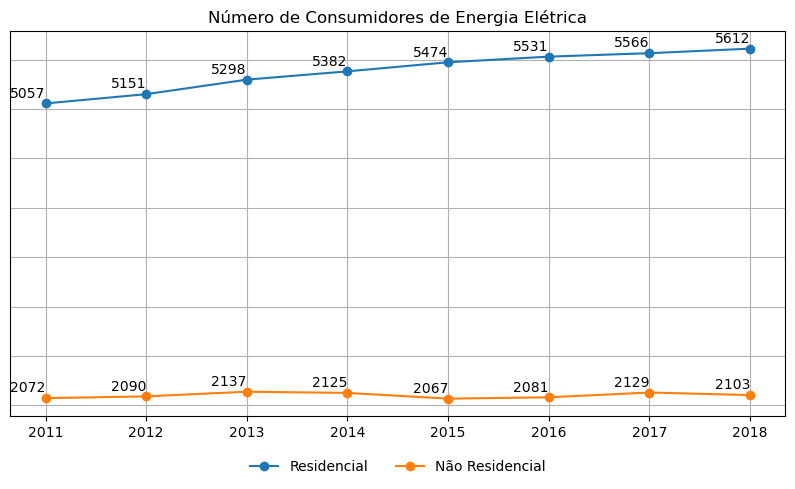

In [41]:
import matplotlib.pyplot as plt

ano = [2011 + i for i in range(8)]
res = [5057,5151,5298,5382,5474,5531,5566,5612]
nres = [2072,2090,2137,2125,2067,2081,2129,2103]

plt.figure(figsize=(10, 5))
plt.plot(ano, res, label='Residencial', marker='o')
plt.plot(ano, nres, label='Não Residencial', marker='o')

# Defina um pequeno deslocamento para os rótulos dos pontos
offset = 60

for i in range(len(ano)):
    plt.text(ano[i], res[i] + offset, res[i], ha='right')  # Ajuste y com um offset
    plt.text(ano[i], nres[i] + offset, nres[i], ha='right')  # Ajuste y com um offset

plt.xlabel('')
plt.ylabel('')
plt.title('Número de Consumidores de Energia Elétrica')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
plt.tick_params(axis='y', which='both', left=False, labelleft=False)
plt.grid(axis='y')  # Show grid lines only along the y-axis
plt.grid(axis='x')  # Show grid lines only along the x-axis

plt.savefig('energia.png', dpi=300, bbox_inches='tight')
plt.show()


# Ajuste de dados - tecnologia telefônica
fontes: https://informacoes.anatel.gov.br/paineis/outorga-e-licenciamento/estacoes-do-smp (para isso) e https://informacoes.anatel.gov.br/paineis/infraestrutura/panorama (outros dados usados)

In [55]:
bd = pd.read_excel('tecnologia telefonica RS.xlsx').groupby(['Município','Número Estação','Operadora','Endereço (Rua, Nº, Comp., Bairro)','Latitude decimal', 'Longitude decimal']).agg({
    'Geração': lambda x: ' / '.join(x.unique()),
    'Tecnologia': lambda x: ' / '.join(x.unique())
}).reset_index()

cidades = ['São Pedro do Sul','Cerro Grande do Sul','Taquara','Butiá','Morro Reuter','Jaguari','Lagoa Bonita do Sul']
for cidade in cidades:
    bd_cidade = bd[bd["Município"] == cidade]
    bd_cidade.to_csv(f'tecnologia telefonica {cidade}.csv', decimal=',', encoding='latin1', sep=';', index=False)